## Vectore Embeddings and Vector Store [LangChain]:

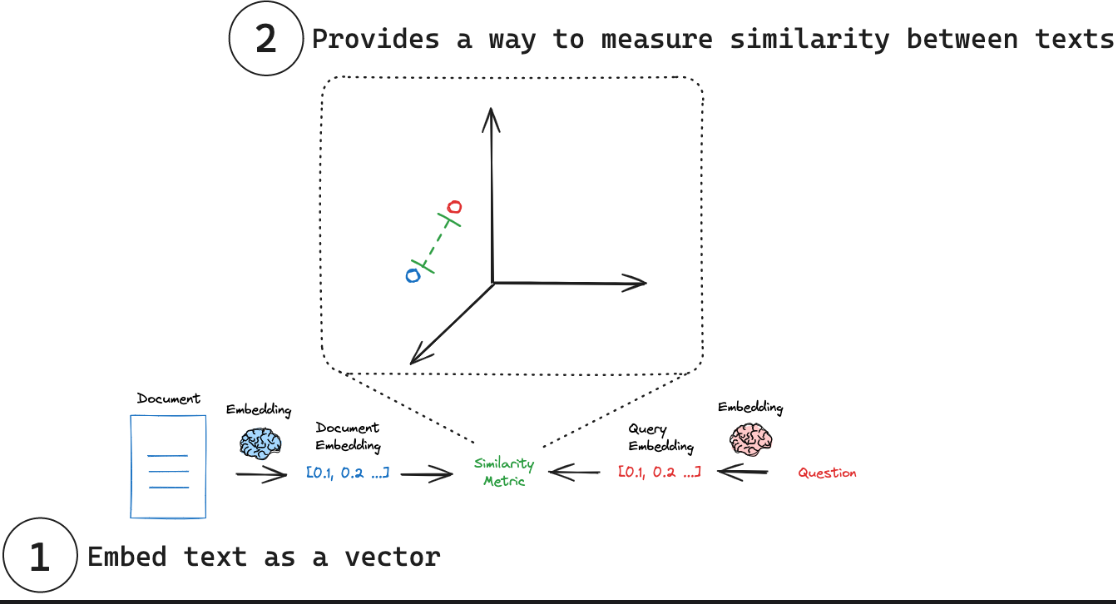
src: [langchain 🔗](https://python.langchain.com/docs/concepts/embedding_models/)

### Vector Embedding Models:

- Converting the loaded documents into the vectors (embeddings).

In [111]:
import os 
from dotenv import load_dotenv
from langchain.document_loaders import TextLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.rate_limiters import InMemoryRateLimiter

constants:

In [83]:
SAMPLES_DIR = os.path.abspath('samples')
TEXT_FILE_PATH = os.path.join(SAMPLES_DIR, 'essay.txt')
PDF_FILE_PATH = os.path.join(SAMPLES_DIR, 'my-resume.pdf')

Loading the document:

In [84]:
document_loader = TextLoader(file_path = TEXT_FILE_PATH,
                             autodetect_encoding=True)


document = document_loader.load()[0]

In [85]:
print(f"""Loaded Document Details:
metadata: {document.metadata}
content: 
{document.page_content[:int(len(document.page_content)/6)]}...
""")

Loaded Document Details:
metadata: {'source': 'e:\\00_SCULPTSOFT\\training-internship\\Training-Tasks---SculptSoft\\Gen AI - LLMs\\basics\\samples\\essay.txt'}
content: 
India: A Diverse Nation with a Glorious Past and Promising Future

    India, officially known as the Republic of India, is a nation that stands as a testament to unity in diversity. With its rich cultural heritage, deep historical roots, varied geographical features, and dynamic economy, India holds a unique place in the world. From ancient civilizations to being a global leader in technology and innovation, Indiaâ€™s journey is a fascinating blend of tradition and modernity.

Historical Significance
    India is home to one of the worldâ€™s oldest civilizations â€” the Indus Valley Civilization â€” which flourished around 2500 BCE. The civilization demonstrated advanced urban planning, architecture, and socio-economic structures. Over the centuries, India becam...



Splitting the document:

In [86]:
from langchain.text_splitter import TokenTextSplitter

In [103]:
t_splitter = TokenTextSplitter(
    chunk_size = 100,
    chunk_overlap = 10
)

In [117]:
chunks = t_splitter.split_text(document.page_content)

print(f"""
Original Document Length: {len(document.page_content)} chars
---
Chunks length: {len(chunks)}
""")

chunks = chunks[:5]
chunks


Original Document Length: 4641 chars
---
Chunks length: 12



['India: A Diverse Nation with a Glorious Past and Promising Future\n\n    India, officially known as the Republic of India, is a nation that stands as a testament to unity in diversity. With its rich cultural heritage, deep historical roots, varied geographical features, and dynamic economy, India holds a unique place in the world. From ancient civilizations to being a global leader in technology and innovation, Indiaâ€™s journey is a fascinating blend of tradition and modernity.\n\n',
 ' fascinating blend of tradition and modernity.\n\nHistorical Significance\n    India is home to one of the worldâ€™s oldest civilizations â€” the Indus Valley Civilization â€” which flourished around 2500 BCE. The civilization demonstrated advanced urban planning, architecture, and socio-economic structures. Over the centuries, India became a hub for major empires and dynasties, such as the Mauryas, Guptas, Cholas, M',
 "as, Guptas, Cholas, Mughals, and later the British Empire. Each of these periods 

---

### Google gemini's based embeddings:

- To convert the document into the vectors.

In [118]:
embedding_model_name = 'models/gemini-embedding-exp-03-07'

In [119]:
load_dotenv()
GOOGLE_AI_API_KEY = os.getenv("GOOGLE_API_KEY")

In [120]:
rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.08,
)

In [121]:
embeddings = GoogleGenerativeAIEmbeddings(
    model = embedding_model_name,
    rate_limiter = rate_limiter,
    google_api_key=GOOGLE_AI_API_KEY
)

In [ ]:
import time 
from tqdm import tqdm
vectors = []

for i, chunk in zip(tqdm(range(len(chunks))), chunks):
    vectors.append(embeddings.embed_query(chunk))

100%|██████████| 5/5 [00:05<00:00,  1.02s/it]


In [131]:
vectors_tmp = embeddings.embed_documents(texts=chunks)

In [135]:
print(f"""Dimensions of the vectors [embeddings] generated:
{len(vectors)} x {len(vectors[0])}
""")

Dimensions of the vectors [embeddings] generated:
5 x 3072



---

## Vector Store:


- Now, the above generated embeddings can be stored in Vector Database / In-memory vector stores and can be used as a resource for LLM. 
- This is the basics of RAG (Retrieval-Augmented Generation)

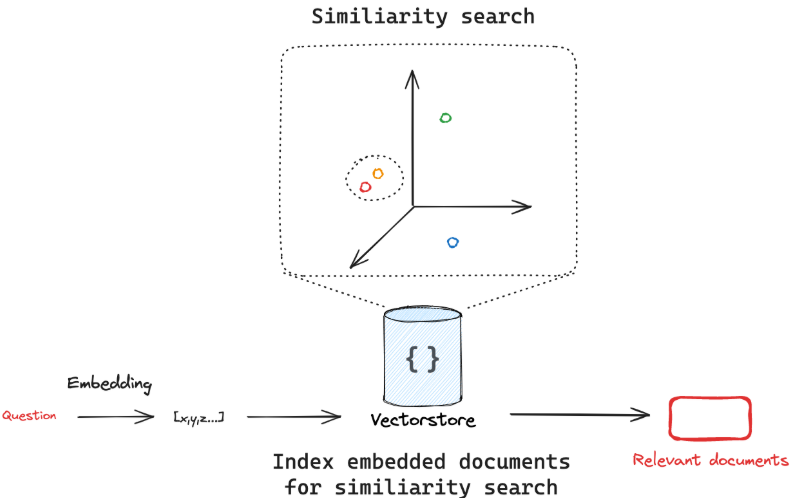
src: [langchain's vector stores 🔗](https://python.langchain.com/docs/concepts/vectorstores/)

### Langchain's In-Memory Vector store:

In [136]:
from langchain_core.vectorstores import InMemoryVectorStore

In [137]:
vector_store = InMemoryVectorStore(
    embedding = embeddings
)

In [ ]:
vector_store.add_texts(chunks)

['e7b6d7af-82e4-4127-8132-05b72b1e9f99',
 'ecdf3548-8232-4dc6-a49a-a463d0963f21',
 'dc359f35-d1ea-477d-bc6d-acc2b3715934',
 '57ba0714-619b-437b-a116-423fc4fc1bbf',
 'b49d3a70-edb6-4f42-b454-00bd86071d8b']

- Added the vectors to the vector store (as of now using in-memory store) similarly there are available vector databases like chromadb, pinecone, etc...

- Now, Let's perform the similarity search to search for the specific data from the store via query...

In [142]:
query = "Republic of India."

In [ ]:
docs = vector_store.similarity_search(query, k=1, )
docs

[Document(id='e7b6d7af-82e4-4127-8132-05b72b1e9f99', metadata={}, page_content='India: A Diverse Nation with a Glorious Past and Promising Future\n\n    India, officially known as the Republic of India, is a nation that stands as a testament to unity in diversity. With its rich cultural heritage, deep historical roots, varied geographical features, and dynamic economy, India holds a unique place in the world. From ancient civilizations to being a global leader in technology and innovation, Indiaâ€™s journey is a fascinating blend of tradition and modernity.\n\n')]

Retrieved Document from the vector store:

In [150]:
print(f"""Search Query: >>> "{query}"
Retrieved Content:
    {docs[0].page_content}""")

Search Query: >>> "Republic of India."
Retrieved Content:
    India: A Diverse Nation with a Glorious Past and Promising Future

    India, officially known as the Republic of India, is a nation that stands as a testament to unity in diversity. With its rich cultural heritage, deep historical roots, varied geographical features, and dynamic economy, India holds a unique place in the world. From ancient civilizations to being a global leader in technology and innovation, Indiaâ€™s journey is a fascinating blend of tradition and modernity.




---

**More Practice:**

- Adding my resume in vector store and will retrieve the content as required.

In [151]:
resume_path = os.path.join(SAMPLES_DIR, 'my-resume.pdf')

In [152]:
from langchain.document_loaders import PyPDFLoader

In [160]:
resume_loader = PyPDFLoader(
    file_path=resume_path, 
)

cv_docs = resume_loader.load()
cv_docs

[Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2025-04-24T11:25:03+00:00', 'title': 'SculpSoft - Resume', 'moddate': '2025-04-24T11:25:02+00:00', 'keywords': 'DAGliug431E,BAERE5KljWo,0', 'author': 'KIRTAN GHELANI', 'source': 'e:\\00_SCULPTSOFT\\training-internship\\Training-Tasks---SculptSoft\\Gen AI - LLMs\\basics\\samples\\my-resume.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Achievements\nO t h \nSRM Institute of Science and Technology\nB.Tech in Computer Science and Engineering.\nCGPA: 9.34 (93.4%).\nRelevant coursework: Software Engineering, AI, DSA, OOPS, DBMS, Applied programming, Analysis of algorithms. \nSeptember 2020 - October 2024\n+ 9 1 - 8 0 0 0 8 2 3 6 5 4 \n G i t h u b : g i t h u b . c o m / g h e l a n i k i r t a n \nl i n k e d i n . c o m / i n / k i r t a n - g h e l a n i L i n k e d I n : \nP o r t f o l i o : g h e l a n i k i r t a n . v e r c e l . a p p \nk g h e l a n i . d e v @ g m a i l . c o m \n 

Adding this documents to vector store using the embeddings model we created:

In [163]:
resume_vector_store = InMemoryVectorStore(
    embedding=embeddings
)

In [165]:
resume_vector_store.add_documents(cv_docs)

['286d6654-1622-4495-b647-915aae75f667',
 'd0722a4b-4a54-49f5-8a7c-295d8e32c262']

Let's retrieve the page of the resume with the query (similarity Search):

In [166]:
query = "KIRTAN YOGESHKUMAR GHELANI"

In [168]:
retrieved_doc = resume_vector_store.similarity_search(query, k=1)
retrieved_doc

[Document(id='286d6654-1622-4495-b647-915aae75f667', metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2025-04-24T11:25:03+00:00', 'title': 'SculpSoft - Resume', 'moddate': '2025-04-24T11:25:02+00:00', 'keywords': 'DAGliug431E,BAERE5KljWo,0', 'author': 'KIRTAN GHELANI', 'source': 'e:\\00_SCULPTSOFT\\training-internship\\Training-Tasks---SculptSoft\\Gen AI - LLMs\\basics\\samples\\my-resume.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Achievements\nO t h \nSRM Institute of Science and Technology\nB.Tech in Computer Science and Engineering.\nCGPA: 9.34 (93.4%).\nRelevant coursework: Software Engineering, AI, DSA, OOPS, DBMS, Applied programming, Analysis of algorithms. \nSeptember 2020 - October 2024\n+ 9 1 - 8 0 0 0 8 2 3 6 5 4 \n G i t h u b : g i t h u b . c o m / g h e l a n i k i r t a n \nl i n k e d i n . c o m / i n / k i r t a n - g h e l a n i L i n k e d I n : \nP o r t f o l i o : g h e l a n i k i r t a n . v e r c e l . a p p \nk g 

In [169]:
print(f"""
Retrieved Page:
{retrieved_doc[0].page_content}""")


Retrieved Page:
Achievements
O t h 
SRM Institute of Science and Technology
B.Tech in Computer Science and Engineering.
CGPA: 9.34 (93.4%).
Relevant coursework: Software Engineering, AI, DSA, OOPS, DBMS, Applied programming, Analysis of algorithms. 
September 2020 - October 2024
+ 9 1 - 8 0 0 0 8 2 3 6 5 4 
 G i t h u b : g i t h u b . c o m / g h e l a n i k i r t a n 
l i n k e d i n . c o m / i n / k i r t a n - g h e l a n i L i n k e d I n : 
P o r t f o l i o : g h e l a n i k i r t a n . v e r c e l . a p p 
k g h e l a n i . d e v @ g m a i l . c o m 
 M e d i u m : g h e l a n i k . m e d i u m . c o m 
Proof URL HackRx 4.0 Gen AI Hackathon: FinalistsJuly 2023
Proof URL HACK SRM 4.0 Hackathon: Best in Blockchain title winnerMay 2023
Proof URL Project Expo’23: “AI in healthcare” themeFebruary 2023
Google Kickstart 2021April 2021 Proof URL 
Education
Chennai, India
|
KIRTAN YOGESHKUMAR GHELANI
|
 Skills
Projects
StylCheck - Visual Testing at Scale
Built at HackRx 4.0, a generat

---

By Kirtan Ghelani `@SculptSoft`